## Equation-Oriented Operability: Pyomo Models in opyrability

Author: Victor Alves - Carnegie Mellon University

opyrability is model agnostic: any Python callable that maps inputs to outputs works. This tutorial showcases a second, **equation-oriented** route: passing a **Pyomo model builder** instead of a callable. The mapping functions auto-detect it and solve the algebraic problem directly, with exact derivatives from the Pyomo expression graph instead of finite differences. This is particularly useful for rigorous thermodynamic models, flowsheets, or neural networks embedded through OMLT.

The example is a **continuous stirred-tank reactor (CSTR)** with consecutive reactions A $\rightarrow$ B $\rightarrow$ C, whose Achievable Output Set is nonconvex. In this case study, some of opyrability's features are highlighted, such as:

-  Automatic detection of Pyomo/OMLT models in ``nlp_based_approach`` (inverse mapping) and ``AIS2AOS_map`` (forward mapping)
-  Switching the NLP solver with a single argument: ``pyomo_solver='ipopt'`` or ``pyomo_solver='pounce'``
-  The forward-mapping simulation proxy

This capability was originally suggested by Heitor F. (github [@hfsf](https://github.com/hfsf), PR #33, and adapted into opyrability).

### Writing the model as a Pyomo builder

The builder contract is a function ``model(m, u, y)`` that adds the process constraints linking the input variables ``u`` to the output variables ``y`` on a Pyomo ``ConcreteModel`` ``m``, flagged with a ``build_pyomo_constraints`` attribute so opyrability auto-detects it. For the CSTR the steady-state mass balance for the reactant $C_A$ is the quadratic

$$\text{volume}\,k_1\,C_A^2 + (v_0 + \text{volume}\,k_2)\,C_A - v_0 C_{A,0} = 0,$$

written directly as an equality constraint (no explicit square root needed), and the intermediate follows from $C_B\,v_0 = k_1 C_A^2\,\text{volume}$. Physical bounds on the concentrations keep the solver on the meaningful root:

In [1]:
import math
import warnings
import numpy as np
import pyomo.environ as pyo

# opyrability prints an informational warning when it auto-detects a Pyomo
# model; the prose below already explains that, so silence it in this tutorial.
warnings.filterwarnings('ignore', message='Pyomo/OMLT model detected')


def build_cstr(m, u, y):
    """
    Pyomo builder for the steady-state CSTR (consecutive reactions A -> B -> C).

    Adds the algebraic constraints linking the inputs ``u`` to the outputs
    ``y`` on the Pyomo model ``m``: the quadratic steady-state mass balance for
    the reactant and the definition of the intermediate. The function is
    flagged with ``build_pyomo_constraints`` so opyrability routes it through
    the equation-oriented path.

    Parameters
    ----------
    m : pyomo.environ.ConcreteModel
        The model the constraints are added to.
    u : indexed Pyomo variable
        Inputs [R, RT]: reactor radius and dimensionless inverse temperature.
    y : indexed Pyomo variable
        Outputs [Ca, Cb]: reactant and intermediate concentrations, bounded to
        the physical range so the solver stays on the meaningful root.

    Returns
    -------
    None
        The constraints are added to ``m`` in place.
    """
    # Inputs  u = [R, RT];  outputs y = [Ca, Cb].
    v0, Ca0, H = 1.0, 1.0, 1.0
    volume = math.pi * u[0] ** 2 * H
    k1 = pyo.exp(-3.0 / u[1])
    k2 = pyo.exp(-10.0 / u[1])

    # Physical bounds and initial guesses on the outputs (concentrations).
    y[0].setlb(1e-6); y[0].setub(Ca0); y[0].value = 0.5
    y[1].setlb(0.0); y[1].value = 0.1

    # Steady-state mass balance for Ca (quadratic) and definition of Cb.
    m.ca_balance = pyo.Constraint(
        expr=volume * k1 * y[0] ** 2 + (v0 + volume * k2) * y[0]
        - v0 * Ca0 == 0)
    m.cb_def = pyo.Constraint(expr=y[1] * v0 == k1 * y[0] ** 2 * volume)


# Flag the builder so opyrability detects the equation-oriented path.
build_cstr.build_pyomo_constraints = True

### Inverse mapping with the Pyomo model

Passing the builder exactly where a callable would go. opyrability detects the Pyomo model, builds one algebraic NLP per DOS grid point, and solves it with Ipopt:

  0%|          | 0/625 [00:00<?, ?it/s]

Termination: {'optimal'}


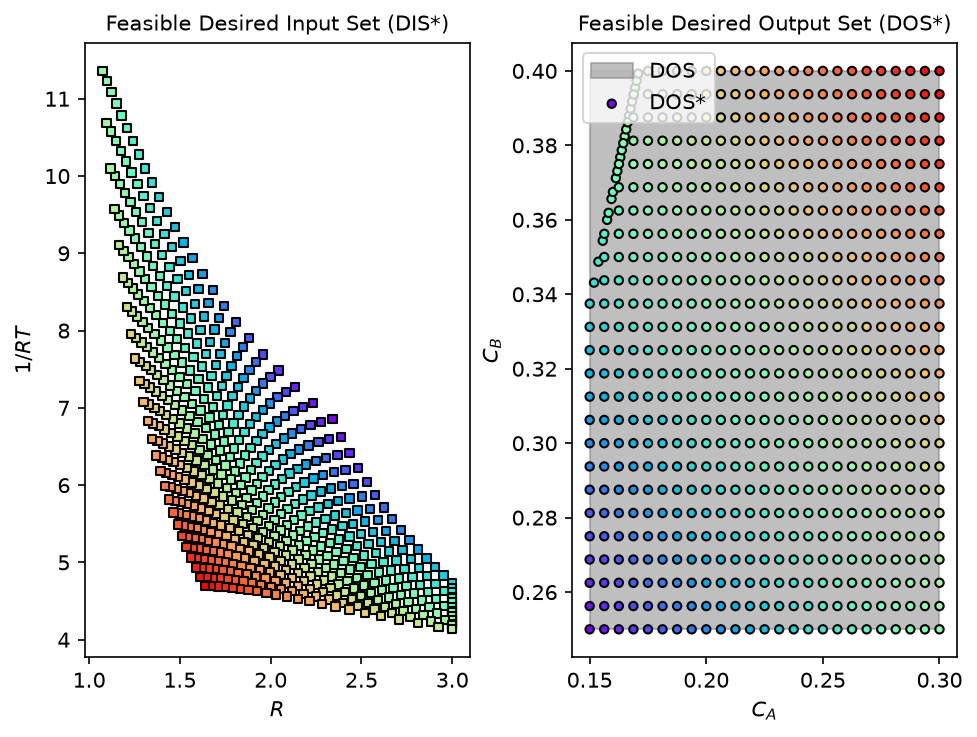

In [2]:
from opyrability import nlp_based_approach

AIS_bounds = np.array([[0.25, 3.00],
                       [1.00, 15.00]])
DOS_bounds = np.array([[0.15, 0.30],
                       [0.25, 0.40]])


u0 = np.array([1.5, 8.0])
lb = np.array([0.25, 1.0])
ub = np.array([3.00, 15.0])
labels = ['$R$', '$1/RT$', '$C_A$', '$C_B$']

fDIS, fDOS, messages = nlp_based_approach(build_cstr, 
                                          DOS_bounds, 
                                          [25, 25], 
                                          u0, 
                                          lb, 
                                          ub,
                                          plot=True,
                                          pyomo_solver='ipopt',
                                          labels=labels)
print('Termination:', set(messages))

### Switching the solver to Pounce: one argument

[Pounce](https://kitchingroup.cheme.cmu.edu/pounce/) is an interior-point NLP solver written in Rust whose nonlinear core is a faithful port of the Ipopt filter line-search algorithm. At each iteration it factorizes the KKT linear system with [FERAL](https://kitchingroup.cheme.cmu.edu/feral/), a sparse symmetric indefinite direct solver also written in Rust, which fills the role the Fortran HSL or MUMPS solvers play inside Ipopt. Because FERAL is bundled, Pounce installs from precompiled wheels with ``pip install pyomo-pounce``. It registers as a standard Pyomo (AMPL-interface) solver, so switching the whole equation-oriented pipeline to Pounce is a one-argument change:

  0%|          | 0/625 [00:00<?, ?it/s]

Termination (Pounce): {'optimal'}
Max difference vs Ipopt, DIS*: 1.24e-14
Max difference vs Ipopt, DOS*: 2.50e-16


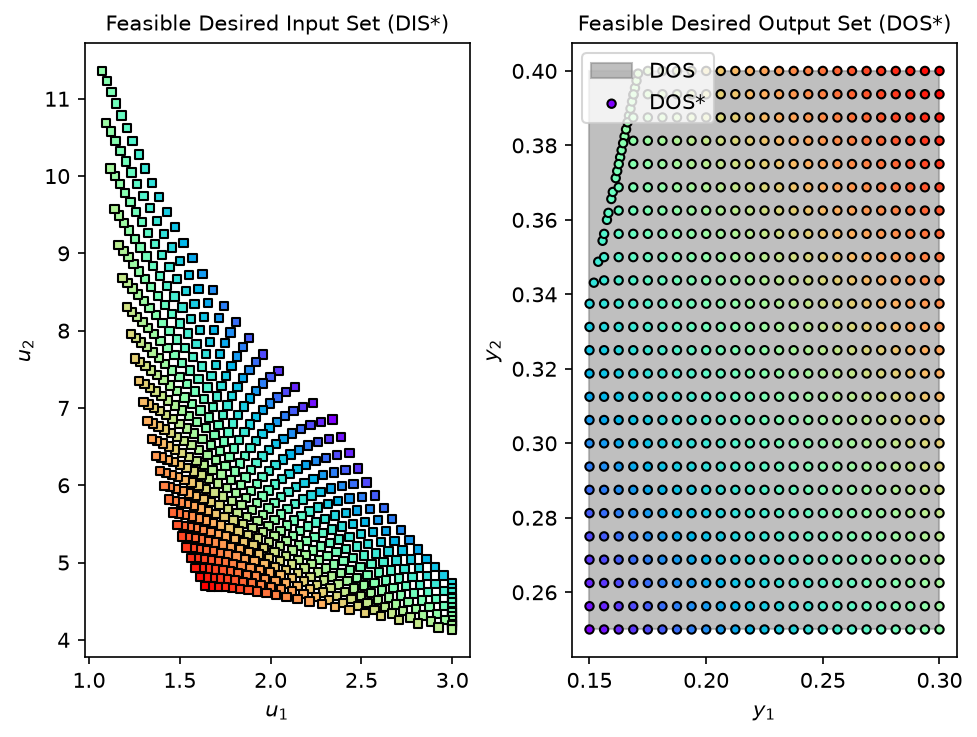

In [5]:
import pyomo_pounce  # registers the 'pounce' solver with Pyomo

fDIS_p, fDOS_p, messages_p = nlp_based_approach(build_cstr, 
                                                DOS_bounds, 
                                                [25, 25], 
                                                u0, lb, ub,
                                                plot=True,
                                                pyomo_solver='pounce')

print('Termination (Pounce):', set(messages_p))
print('Max difference vs Ipopt, DIS*:',
      f'{np.abs(fDIS_p - fDIS).max():.2e}')
print('Max difference vs Ipopt, DOS*:',
      f'{np.abs(fDOS_p - fDOS).max():.2e}')

Both solvers return the same inverse mapping to solver tolerance.

### Forward mapping with the simulation proxy

For the forward mapping, opyrability wraps the algebraic model into a simulation proxy: the inputs are fixed at each grid point and the square system is solved for the outputs. The only extra information needed is ``output_dim`` (the number of outputs, which cannot be inferred from an algebraic model). The curved Achievable Output Set is recovered:

AOS ranges: Ca [0.059, 0.990], Cb [0.010, 0.621]


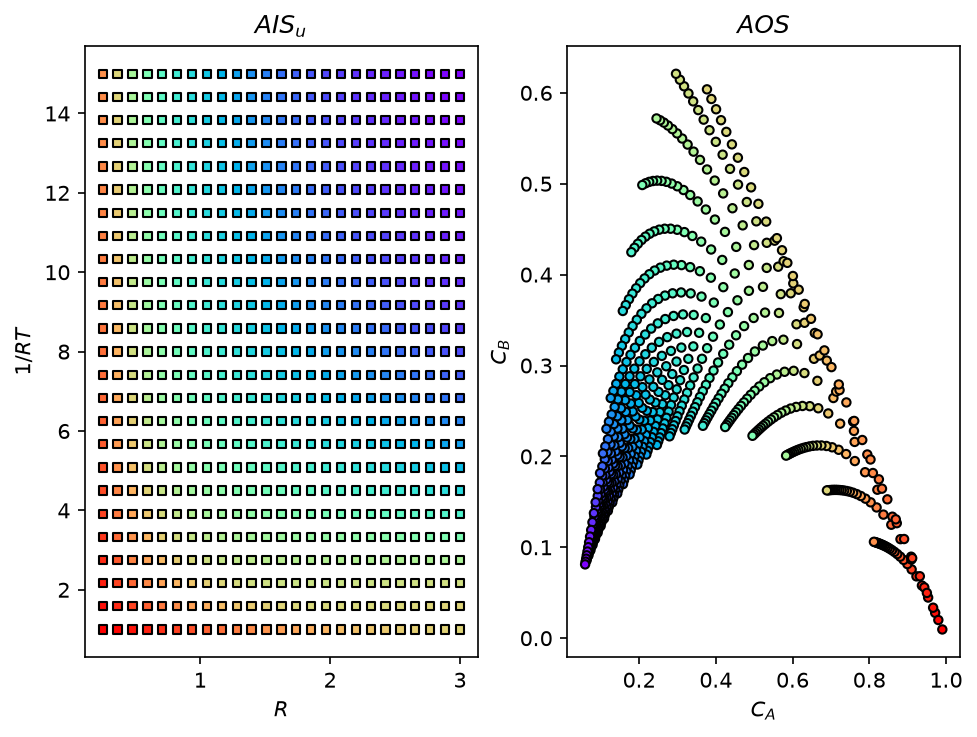

In [4]:
from opyrability import AIS2AOS_map

AIS, AOS = AIS2AOS_map(build_cstr, 
                       AIS_bounds, 
                       [25, 25],
                       output_dim=2,
                       plot=True,
                       labels=labels)
print('AOS ranges: Ca',
      f'[{AOS[..., 0].min():.3f}, {AOS[..., 0].max():.3f}],',
      'Cb',
      f'[{AOS[..., 1].min():.3f}, {AOS[..., 1].max():.3f}]')

### Conclusions

**Key Results:**

- A Pyomo builder dropped into ``nlp_based_approach`` and ``AIS2AOS_map`` with no other code changes: detection, model construction, and solution are automatic.
- The inverse mapping solved through Ipopt and through Pounce agree to solver tolerance; switching solvers is a single argument (``pyomo_solver=``).
- The forward mapping simulates the algebraic model through a proxy, requiring only ``output_dim``, and recovers the curved CSTR output set.

**Workflow Summary:**

1. Write the process model as a Pyomo builder ``model(m, u, y)`` and flag it with ``build_pyomo_constraints = True``.
2. Call ``nlp_based_approach`` or ``AIS2AOS_map`` exactly as with a callable model.
3. Pick the NLP solver with ``pyomo_solver='ipopt'`` or ``'pounce'``.